In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
data = pd.read_csv("data/Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [70]:
data.dropna()
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')

In [71]:
data.isna().sum()

Unnamed: 0                                      0
Time Serie                                      0
AUSTRALIA - AUSTRALIAN DOLLAR/US$               0
EURO AREA - EURO/US$                            0
NEW ZEALAND - NEW ZELAND DOLLAR/US$             0
UNITED KINGDOM - UNITED KINGDOM POUND/US$       0
BRAZIL - REAL/US$                               0
CANADA - CANADIAN DOLLAR/US$                    0
CHINA - YUAN/US$                                0
HONG KONG - HONG KONG DOLLAR/US$                0
INDIA - INDIAN RUPEE/US$                        0
KOREA - WON/US$                                 0
MEXICO - MEXICAN PESO/US$                       0
SOUTH AFRICA - RAND/US$                         0
SINGAPORE - SINGAPORE DOLLAR/US$                0
DENMARK - DANISH KRONE/US$                      0
JAPAN - YEN/US$                                 0
MALAYSIA - RINGGIT/US$                          0
NORWAY - NORWEGIAN KRONE/US$                    0
SWEDEN - KRONA/US$                              0


In [72]:
data = data.drop(columns=["Unnamed: 0", "Unnamed: 24"], errors="ignore")

In [73]:
data = data.sort_values("Time Serie").reset_index(drop=True)

In [74]:
for col in data.columns:
    if col != "Time Serie":
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [75]:
data = data.ffill().bfill()

In [76]:
print("Shape:", data.shape)
data.info()

Shape: (5217, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   float64       
 2   EURO AREA - EURO/US$                       5217 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   float64       
 5   BRAZIL - REAL/US$                          5217 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   float64       
 7   CHINA - YUAN/US$                           5217 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   float64       
 9   I

In [77]:
data["Time Serie"].diff().value_counts()

Time Serie
1 days    4173
3 days    1043
Name: count, dtype: int64

In [78]:
data.describe()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
count,5217,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,...,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000
mean,2009-12-31 09:36:19.873490688,1.332284,0.844061,1.543651,0.640725,2.550569,1.230577,7.199286,7.782593,52.759603,...,1.480183,6.287160,106.592321,3.651972,7.078344,7.901722,119.200501,1.150089,31.766274,35.519478
min,2000-01-03 00:00:00,0.906900,0.624600,1.134600,0.473800,1.537500,0.916800,6.040200,7.708500,38.480000,...,1.200700,4.660500,75.720000,2.937000,4.946700,5.834600,72.300000,0.729600,28.500000,28.600000
25%,2004-12-31 00:00:00,1.115800,0.751100,1.323600,0.587900,1.946000,1.056000,6.475800,7.756300,45.270000,...,1.342600,5.594500,100.080000,3.292000,5.998800,6.853000,100.400000,0.966800,30.350000,31.780000
50%,2009-12-31 00:00:00,1.311500,0.815800,1.442600,0.636600,2.331000,1.237200,6.859700,7.780600,48.110000,...,1.408400,6.074000,109.060000,3.800000,6.786000,7.751000,112.350000,1.038600,31.730000,34.000000
75%,2014-12-31 00:00:00,1.430600,0.900300,1.591100,0.692400,3.132000,1.335700,8.276500,7.799800,62.470000,...,1.678700,6.715300,116.820000,3.800000,8.281300,8.747400,132.800000,1.268700,32.980000,39.410000
max,2019-12-31 00:00:00,2.071300,1.209200,2.551000,0.828700,4.259400,1.612800,8.280000,7.849900,74.330000,...,1.854000,9.005000,134.770000,4.496000,9.589000,11.027000,182.800000,1.825000,35.210000,45.820000
std,NaN,0.269792,0.126685,0.337116,0.082641,0.725318,0.182147,0.819876,0.027558,9.694685,...,0.188831,0.942385,13.221191,0.379180,1.227016,1.201698,25.409982,0.248856,1.670693,4.562211


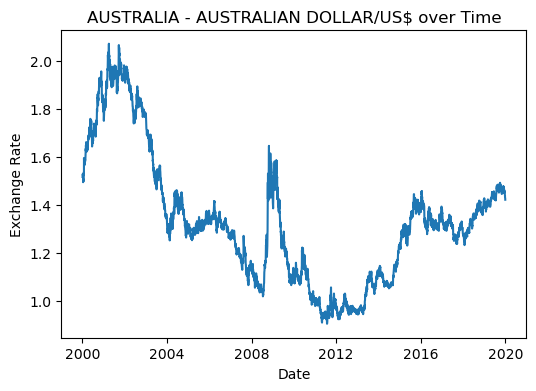

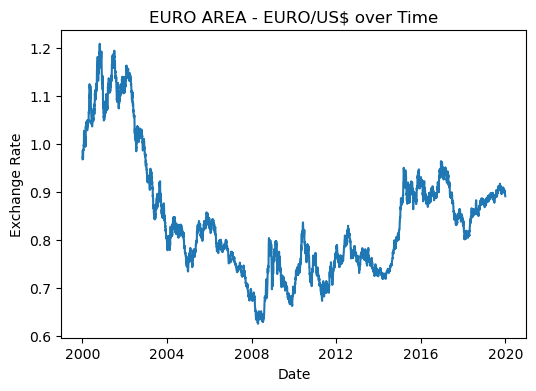

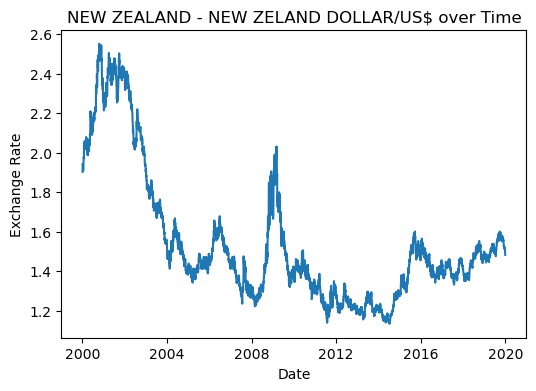

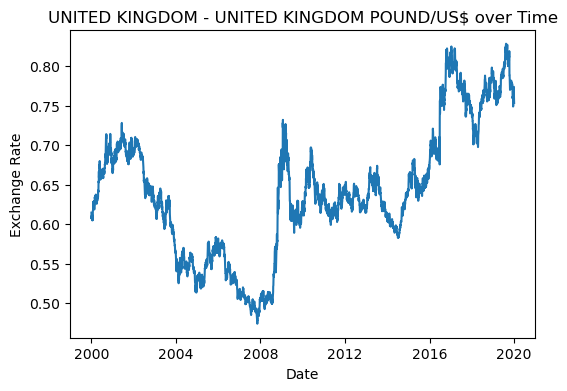

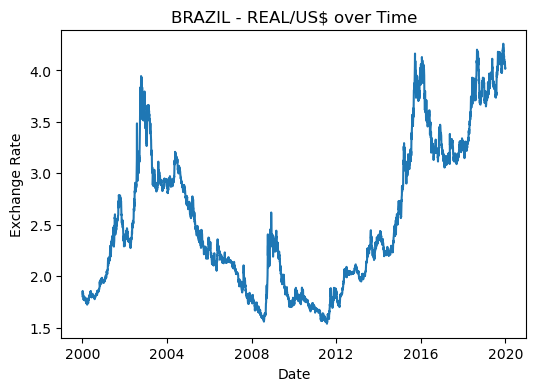

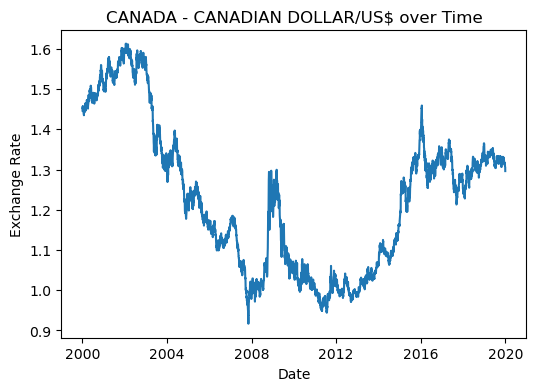

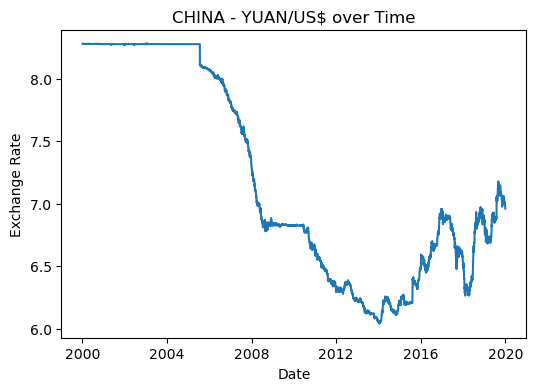

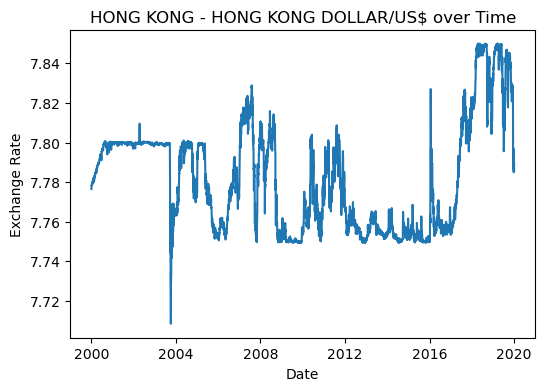

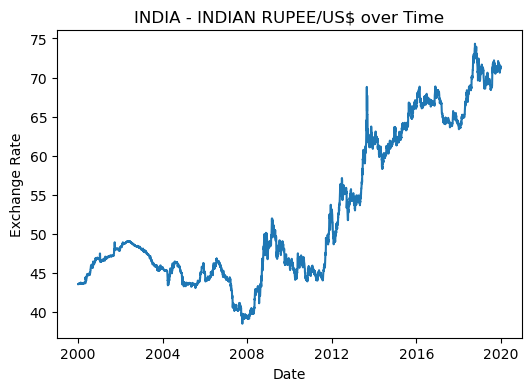

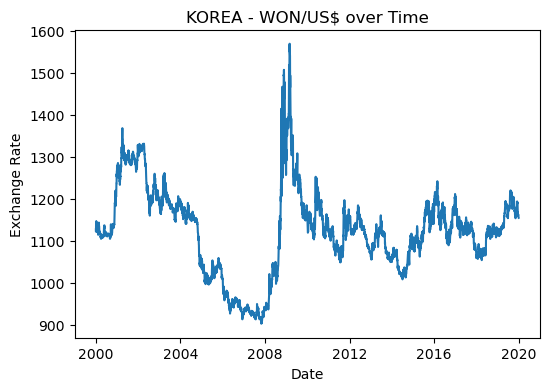

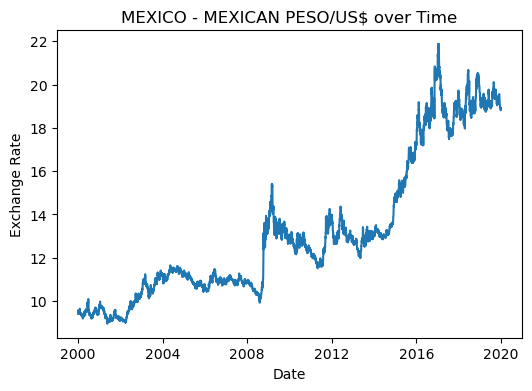

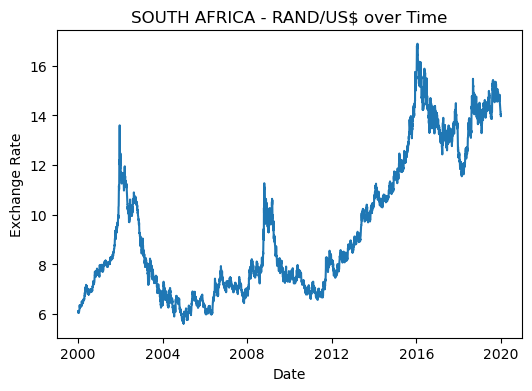

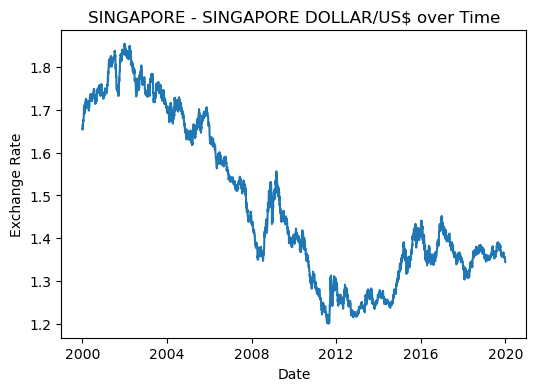

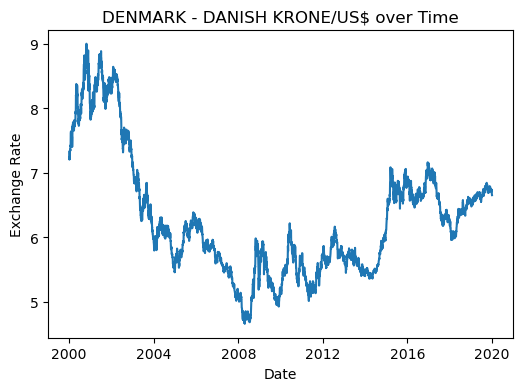

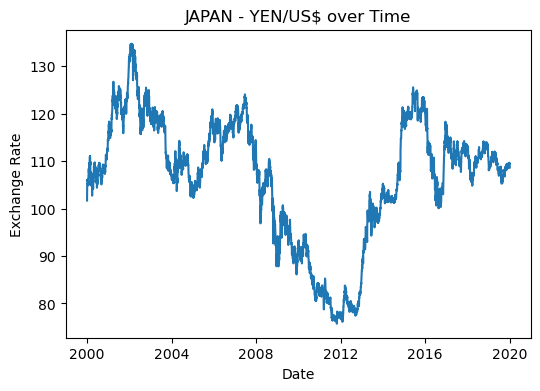

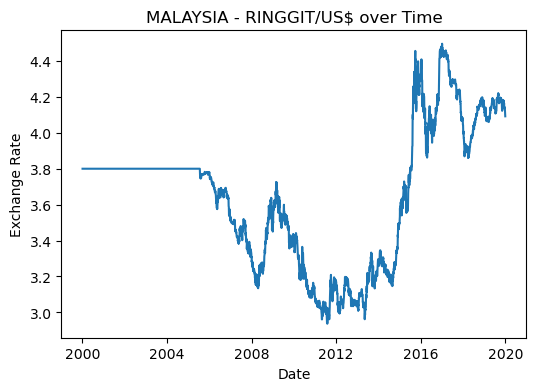

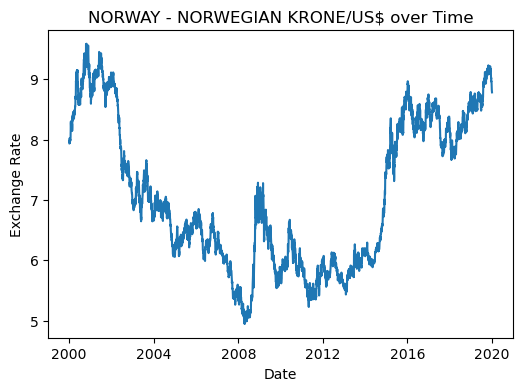

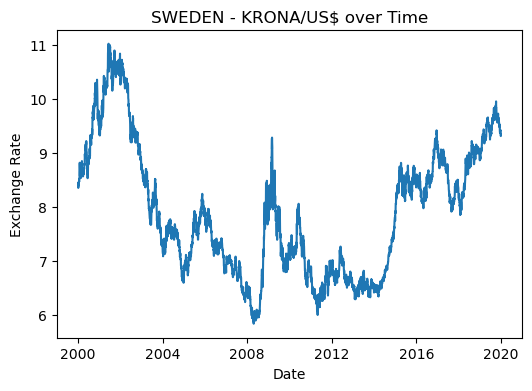

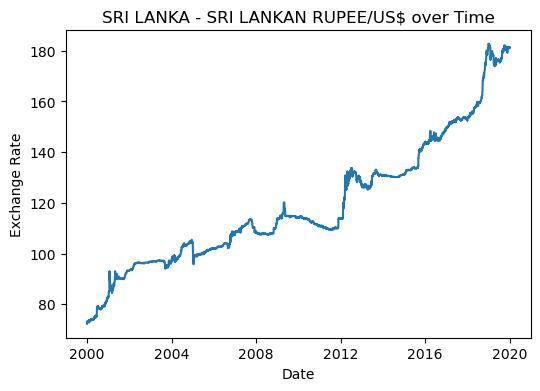

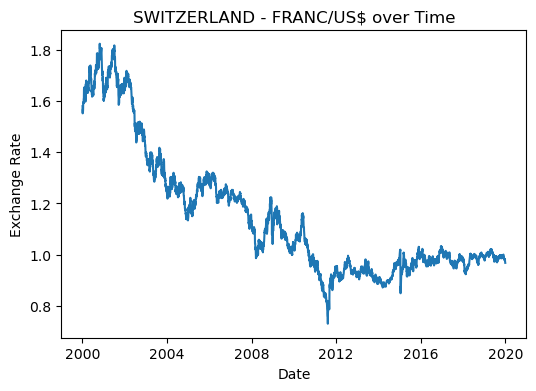

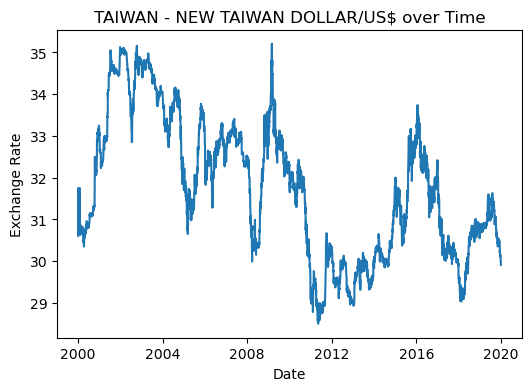

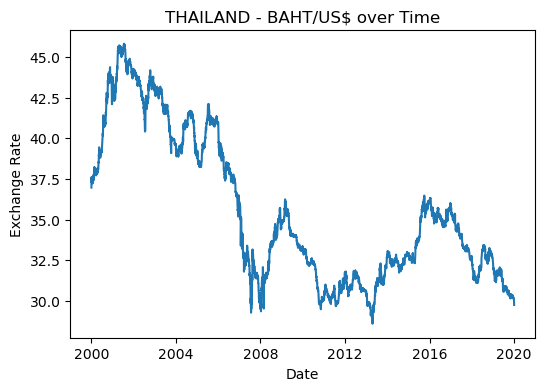

In [79]:
sample_currencies = [
    "EURO AREA - EURO/US$",
    "JAPAN - YEN/US$",
    "UNITED KINGDOM - UNITED KINGDOM POUND/US$"
]

for col in data.columns.drop('Time Serie'):
    plt.figure(figsize=(6,4))
    plt.plot(data["Time Serie"], data[col])
    plt.title(f"{col} over Time")
    plt.xlabel("Date")
    plt.ylabel("Exchange Rate")
    plt.show()

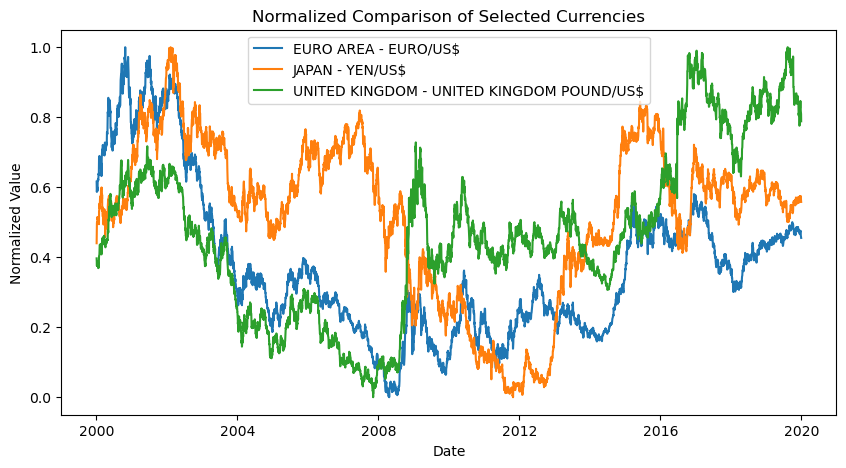

In [80]:
normalized = data[sample_currencies].copy()

normalized = (normalized - normalized.min()) / (normalized.max() - normalized.min())

plt.figure(figsize=(10,5))

for col in sample_currencies:
    plt.plot(data["Time Serie"], normalized[col], label=col)

plt.legend()
plt.title("Normalized Comparison of Selected Currencies")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.show()

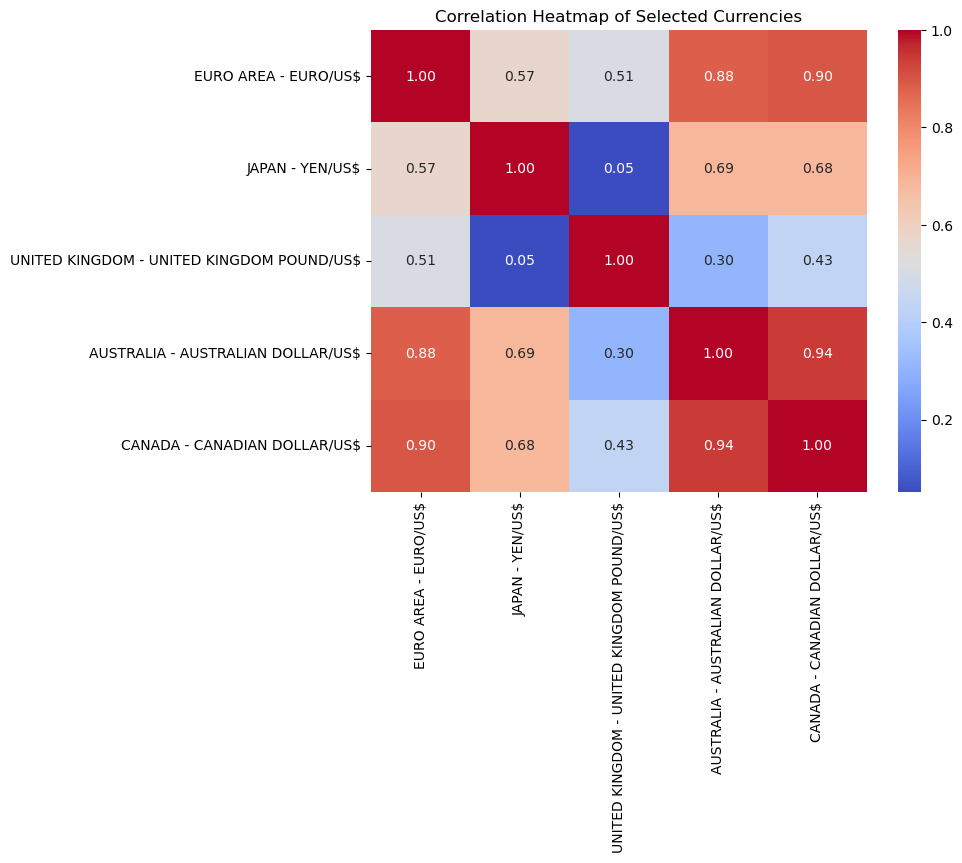

In [81]:
corr_currencies = [
    "EURO AREA - EURO/US$",
    "JAPAN - YEN/US$",
    "UNITED KINGDOM - UNITED KINGDOM POUND/US$",
    "AUSTRALIA - AUSTRALIAN DOLLAR/US$",
    "CANADA - CANADIAN DOLLAR/US$"
]

corr = data[corr_currencies].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Currencies")
plt.show()

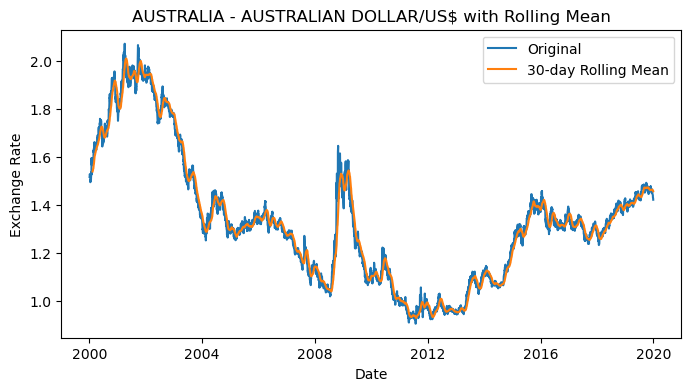

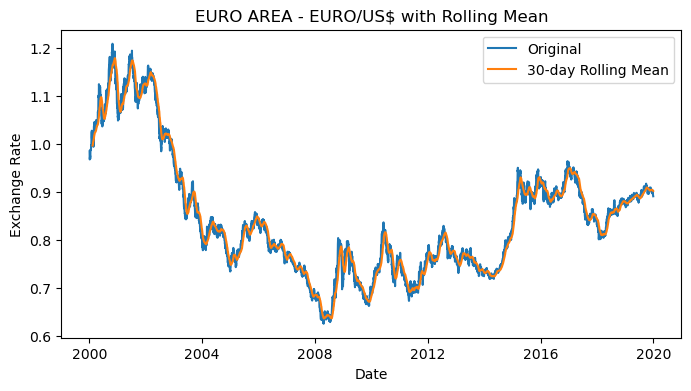

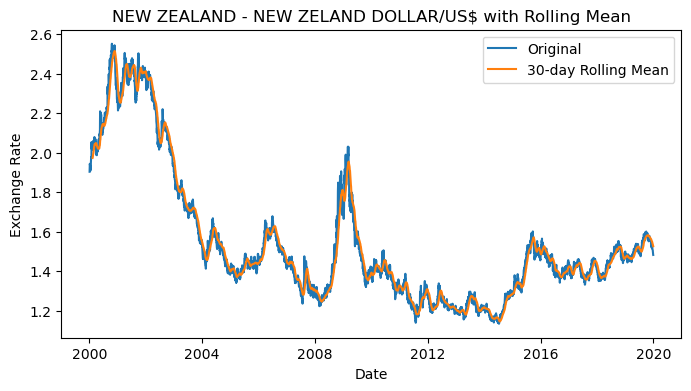

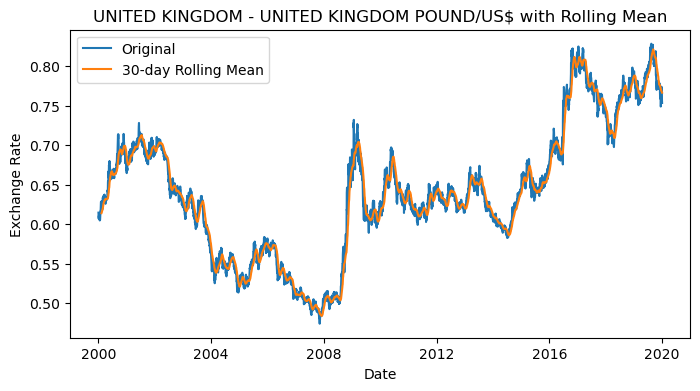

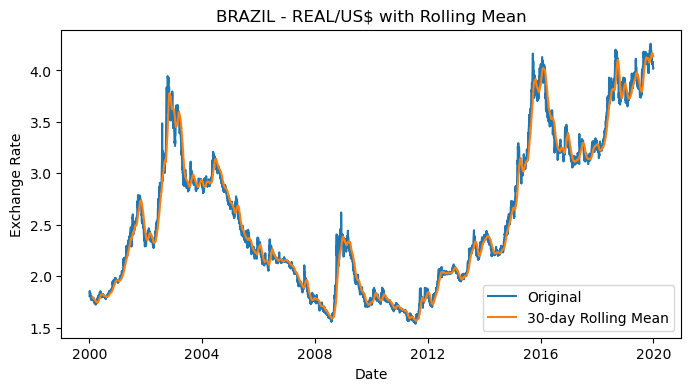

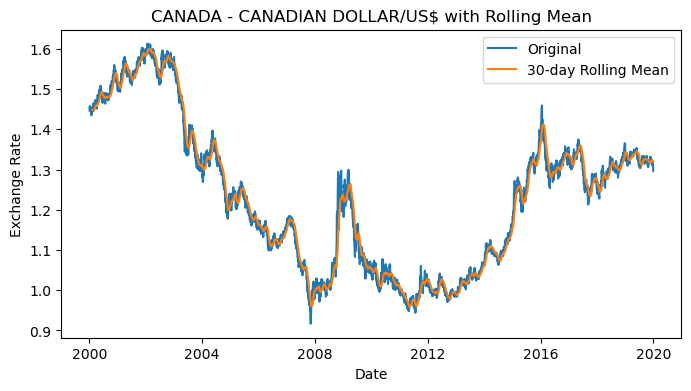

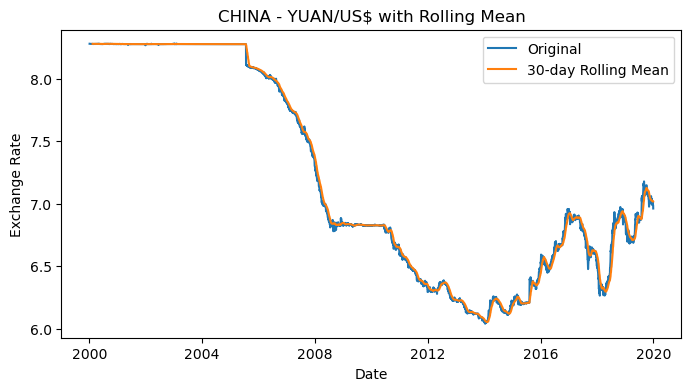

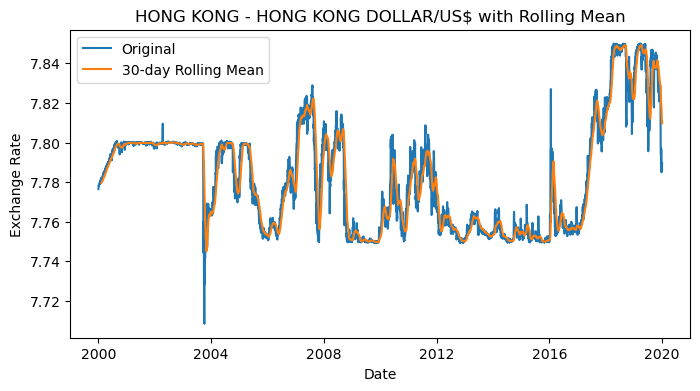

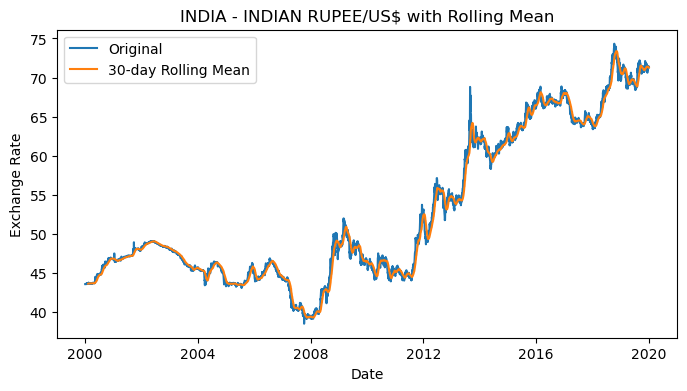

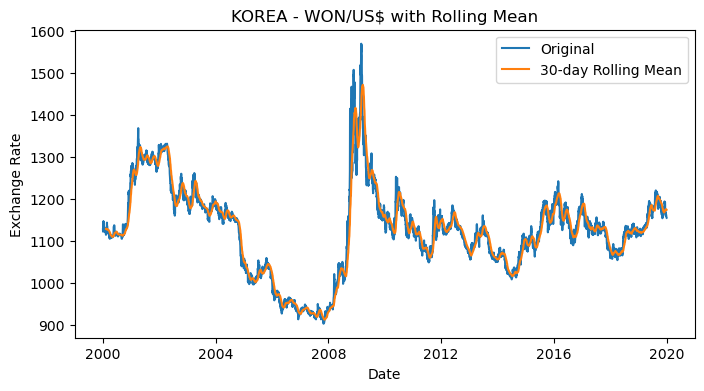

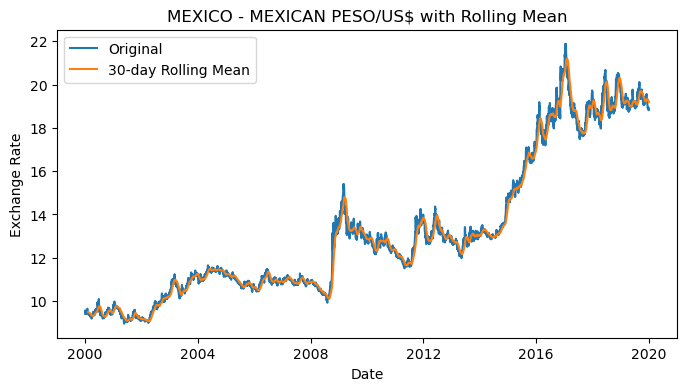

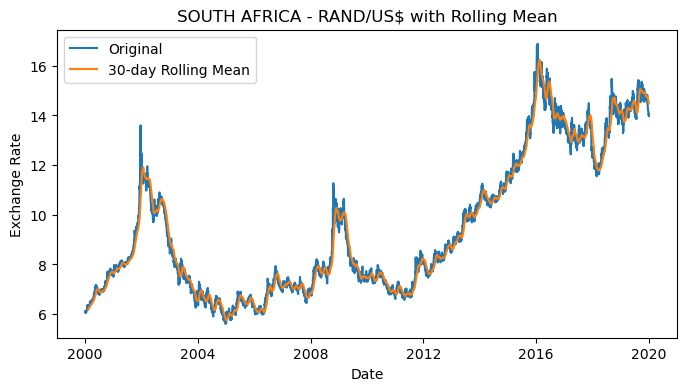

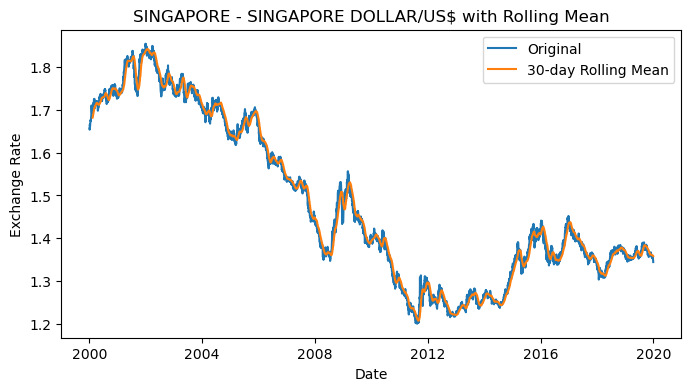

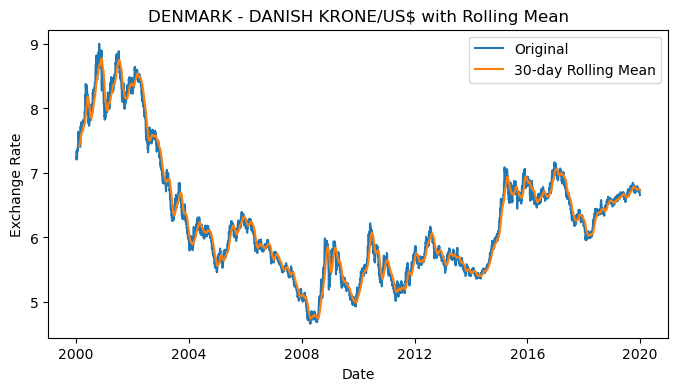

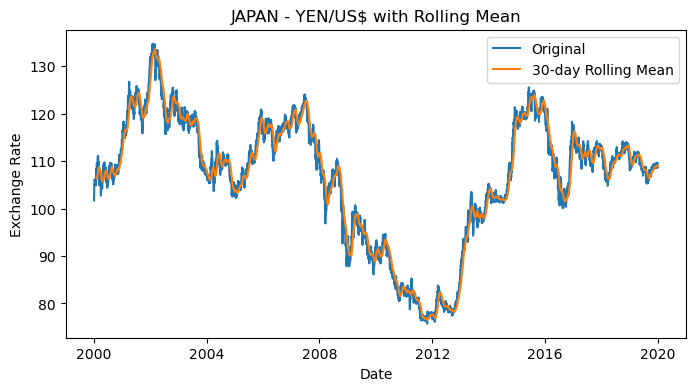

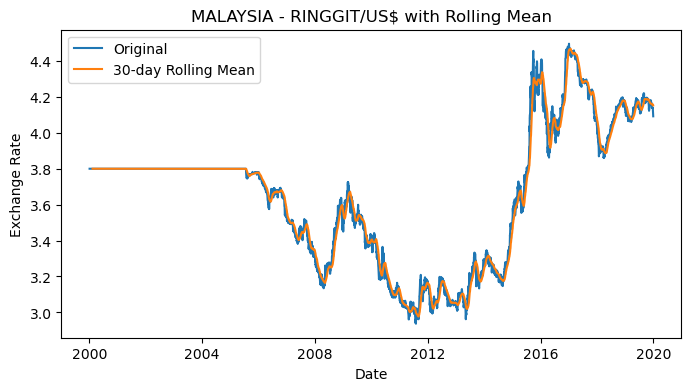

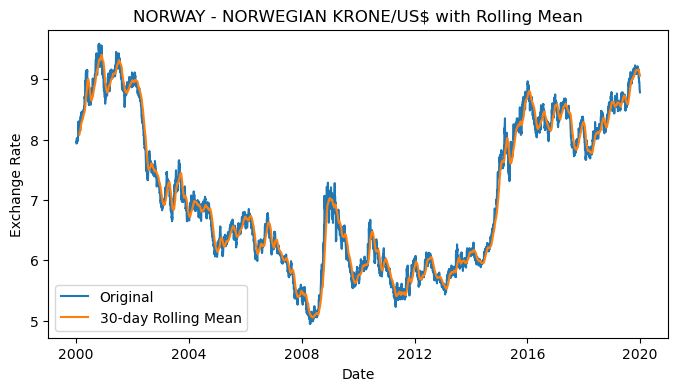

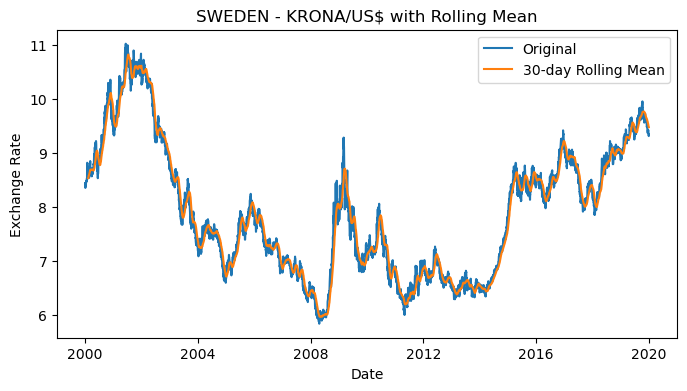

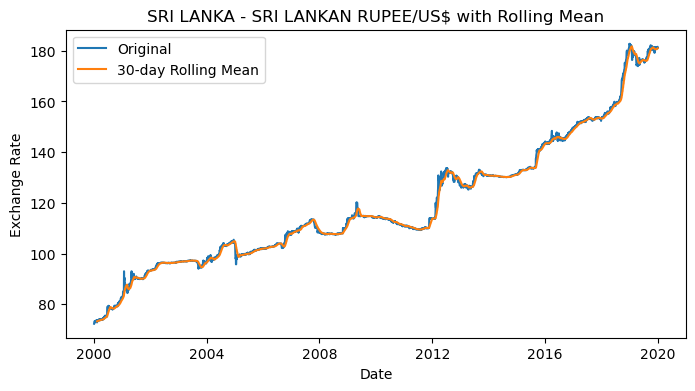

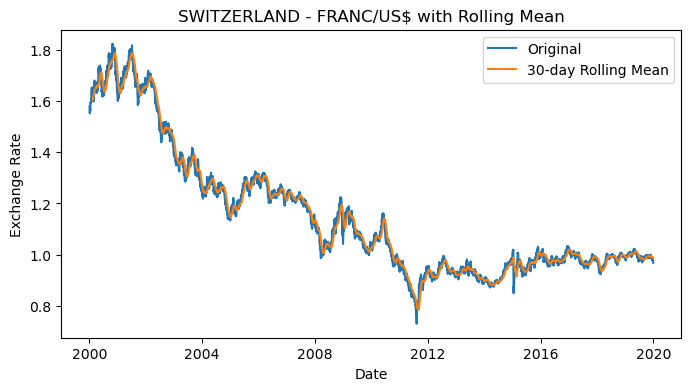

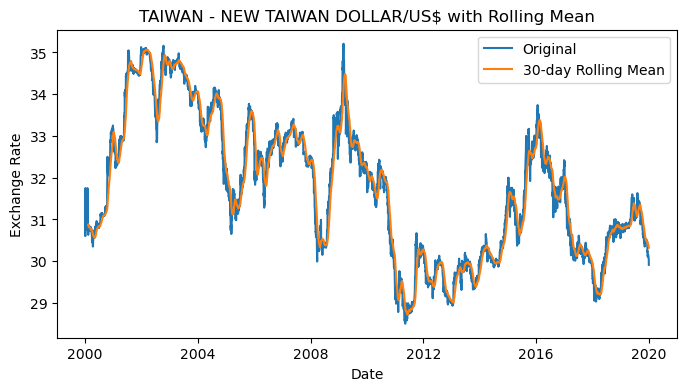

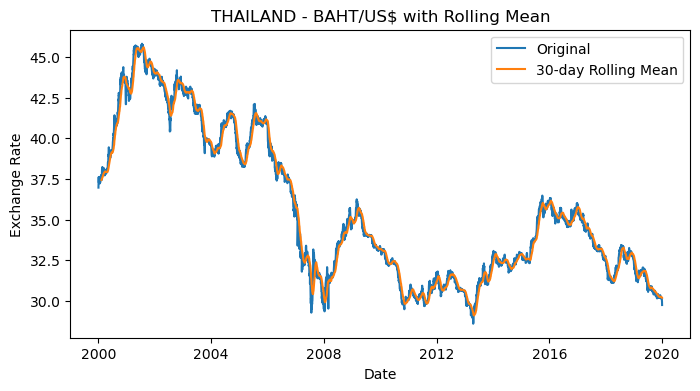

In [82]:
for col in data.columns.drop('Time Serie'):
    plt.figure(figsize=(8,4))
    plt.plot(data["Time Serie"], data[col], label="Original")
    plt.plot(data["Time Serie"], data[col].rolling(window=30).mean(), label="30-day Rolling Mean")
    plt.legend()
    plt.title(f"{col} with Rolling Mean")
    plt.xlabel("Date")
    plt.ylabel("Exchange Rate")
    plt.show()

In [154]:
options = {
    'AUSTRALIAN DOLLAR': 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
    'EURO': 'EURO AREA - EURO/US$',
    'NEW ZEALAND DOLLAR': 'NEW ZEALAND - NEW ZELAND DOLLAR/US$',
    'GREAT BRITAIN POUNDS': 'UNITED KINGDOM - UNITED KINGDOM POUND/US$',
    'BRAZILIAN REAL': 'BRAZIL - REAL/US$',
    'CANADIAN DOLLAR': 'CANADA - CANADIAN DOLLAR/US$',
    'CHINESE YUAN$': 'CHINA - YUAN/US$',
    'HONG KONG DOLLAR': 'HONG KONG - HONG KONG DOLLAR/US$',
    'INDIAN RUPEE': 'INDIA - INDIAN RUPEE/US$',
    'KOREAN WON$': 'KOREA - WON/US$',
    'MEXICAN PESO': 'MEXICO - MEXICAN PESO/US$',
    'SOUTH AFRICAN RAND$': 'SOUTH AFRICA - RAND/US$',
    'SINGAPORE DOLLAR': 'SINGAPORE - SINGAPORE DOLLAR/US$',
    'DANISH KRONE': 'DENMARK - DANISH KRONE/US$',
    'JAPANESE YEN$': 'JAPAN - YEN/US$',
    'MALAYSIAN RINGGIT': 'MALAYSIA - RINGGIT/US$',
    'NORWEGIAN KRONE': 'NORWAY - NORWEGIAN KRONE/US$',
    'SWEDEN KRONA': 'SWEDEN - KRONA/US$',
    'SRILANKAN RUPEE': 'SRI LANKA - SRI LANKAN RUPEE/US$',
    'SWISS FRANC': 'SWITZERLAND - FRANC/US$',
    'NEW TAIWAN DOLLAR': 'TAIWAN - NEW TAIWAN DOLLAR/US$',
    'THAI BAHT': 'THAILAND - BAHT/US$'
}

selected_option = 'SRILANKAN RUPEE'

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return mae, rmse, mape

In [85]:
selected_option = "EURO"
target_col = options[selected_option]

In [86]:
df = data[["Time Serie", target_col]].copy()
df = df.rename(columns={"Time Serie": "ds", target_col: "y"})
df.head()

,ds,y
0,2000-01-03,0.9847
1,2000-01-04,0.9700
2,2000-01-05,0.9676
3,2000-01-06,0.9686
4,2000-01-07,0.9714


In [87]:
train = df.iloc[:-60].copy()
test = df.iloc[-60:].copy()

print(train.shape, test.shape)

(5157, 2) (60, 2)


In [88]:
test["naive_pred"] = train["y"].iloc[-1]
test.head()

,ds,y,naive_pred
5157,2019-10-09,0.9109,0.9133
5158,2019-10-10,0.9076,0.9133
5159,2019-10-11,0.9059,0.9133
5160,2019-10-14,0.9059,0.9133
5161,2019-10-15,0.9061,0.9133


In [89]:
mae_naive, rmse_naive, mape_naive = evaluate(test["y"], test["naive_pred"])

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive MAPE:", mape_naive)

Naive MAE: 0.011016666666666668
Naive RMSE: 0.011867069281559511
Naive MAPE: 1.2233999426617652


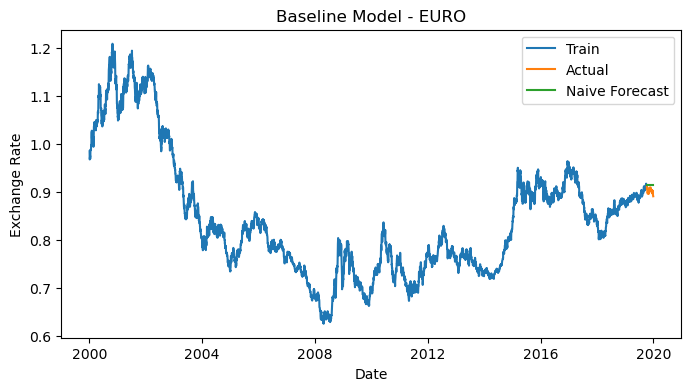

In [90]:
plt.figure(figsize=(8,4))
plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], test["naive_pred"], label="Naive Forecast")
plt.legend()
plt.title("Baseline Model - EURO")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

In [91]:
from prophet import Prophet

In [92]:
train_p = df.iloc[:-60]
test_p = df.iloc[-60:]

In [93]:
model = Prophet()
model.fit(train_p)

11:36:14 - cmdstanpy - INFO - Chain [1] start processing
11:36:17 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

pred = forecast.tail(60)["yhat"].values

In [95]:
mae_prophet, rmse_prophet, mape_prophet = evaluate(test_p["y"], pred)
print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)
print("Prophet MAPE:", mape_prophet)

Prophet MAE: 0.04345067878460825
Prophet RMSE: 0.04414512191040932
Prophet MAPE: 4.813766169850626


In [96]:
from autots import AutoTS

In [97]:
model = AutoTS(
    forecast_length=60,
    frequency="infer",
    model_list="superfast",
    max_generations=1,
    num_validations=1,
    ensemble=None,
    verbose=0
)

In [98]:
model = model.fit(
    train,
    date_col="ds",
    value_col="y",
    id_col=None
)

Template Eval Error: ValueError('maximum supported dimension for an ndarray is currently 64, found 5097') in model 17 in generation 0: BasicLinearModel
Template Eval Error: ValueError('Model SectionalMotif returned NaN for one or more series. fail_on_forecast_nan=True') in model 28 in generation 0: SectionalMotif
Template Eval Error: IndexError('index 3810 is out of bounds for axis 0 with size 1019') in model 34 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 38 in generation 0: SeasonalityMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 49 in generation 0: BasicLinearModel
Template Eval Error: LinAlgError('Singular matrix') in model 51 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 59 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no fu

In [99]:
prediction = model.predict()
forecast = prediction.forecast

forecast = forecast.reset_index()
forecast.columns = ["ds", "y_pred"]

In [100]:
mae_autots, rmse_autots, mape_autots = evaluate(test["y"], forecast["y_pred"])

print("AutoTS MAE:", mae_autots)
print("AutoTS RMSE:", rmse_autots)
print("AutoTS MAPE:", mape_autots)

AutoTS MAE: 0.018040282196010563
AutoTS RMSE: 0.01925997630995654
AutoTS MAPE: nan


In [101]:
!pip install statsmodels

In [102]:
from statsmodels.tsa.arima.model import ARIMA

In [103]:
train_arima = train["y"]
test_arima = test["y"]

In [115]:
results_arima = []

for order in [(1,1,0), (1,1,1), (2,1,1), (3,1,1)]:
    model = ARIMA(train["y"], order=order)
    fitted = model.fit()
    pred = fitted.forecast(steps=len(test))

    mae, rmse, mape = evaluate(test["y"], pred)

    results_arima.append({
        "order": order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

In [116]:
results_arima_df = pd.DataFrame(results_arima)
results_arima_df

,order,MAE,RMSE,MAPE
0,"(1, 1, 0)",0.011044,0.011893,1.226436
1,"(1, 1, 1)",0.011043,0.011891,1.226285
2,"(2, 1, 1)",0.010996,0.011846,1.221094
3,"(3, 1, 1)",0.010986,0.011838,1.220026


In [117]:
best_arima = results_arima_df.sort_values("MAE").iloc[0]
best_arima

order    (3, 1, 1)
MAE       0.010986
RMSE      0.011838
MAPE      1.220026
Name: 3, dtype: object

In [134]:
mae_arima = best_arima["MAE"]
rmse_arima = best_arima["RMSE"]
mape_arima = best_arima["MAPE"]

In [118]:
df_xgb = df.copy()

In [119]:
df_xgb["lag1"] = df_xgb["y"].shift(1)
df_xgb["lag2"] = df_xgb["y"].shift(2)
df_xgb["lag3"] = df_xgb["y"].shift(3)
df_xgb["lag7"] = df_xgb["y"].shift(7)
df_xgb["lag14"] = df_xgb["y"].shift(14)

df_xgb["rolling_mean_7"] = df_xgb["y"].shift(1).rolling(7).mean()
df_xgb["rolling_std_7"] = df_xgb["y"].shift(1).rolling(7).std()

df_xgb["dayofweek"] = df_xgb["ds"].dt.dayofweek
df_xgb["month"] = df_xgb["ds"].dt.month
df_xgb["year"] = df_xgb["ds"].dt.year

In [120]:
df_xgb = df_xgb.dropna().reset_index(drop=True)
df_xgb.head()

,ds,y,lag1,lag2,lag3,lag7,lag14,rolling_mean_7,rolling_std_7,dayofweek,month,year
0,2000-01-21,0.9901,0.9869,0.9886,0.9880,0.9727,0.9847,0.983529,0.007082,4,1,2000
1,2000-01-24,0.9981,0.9901,0.9869,0.9886,0.9737,0.9700,0.986014,0.005532,0,1,2000
2,2000-01-25,0.9959,0.9981,0.9901,0.9869,0.9874,0.9676,0.989500,0.003936,1,1,2000
3,2000-01-26,0.9989,0.9959,0.9981,0.9901,0.9874,0.9686,0.990714,0.004457,2,1,2000
4,2000-01-27,1.0111,0.9989,0.9959,0.9981,0.9880,0.9714,0.992357,0.005104,3,1,2000


In [121]:
train_xgb = df_xgb.iloc[:-60].copy()
test_xgb = df_xgb.iloc[-60:].copy()

print(train_xgb.shape, test_xgb.shape)

(5143, 12) (60, 12)


In [122]:
feature_cols = [
    "lag1", "lag2", "lag3", "lag7", "lag14",
    "rolling_mean_7", "rolling_std_7",
    "dayofweek", "month", "year"
]

X_train = train_xgb[feature_cols]
y_train = train_xgb["y"]

X_test = test_xgb[feature_cols]
y_test = test_xgb["y"]

In [125]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [127]:
test_xgb["xgb_pred"] = xgb_model.predict(X_test)
test_xgb[["ds", "y", "xgb_pred"]].head()

,ds,y,xgb_pred
5143,2019-10-09,0.9109,0.914010
5144,2019-10-10,0.9076,0.910820
5145,2019-10-11,0.9059,0.908568
5146,2019-10-14,0.9059,0.905189
5147,2019-10-15,0.9061,0.905167


In [128]:
mae_xgb, rmse_xgb, mape_xgb = evaluate(y_test, test_xgb["xgb_pred"])

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAPE:", mape_xgb)

XGBoost MAE: 0.0018488753684361833
XGBoost RMSE: 0.002448644229693128
XGBoost MAPE: 0.2050247758723876


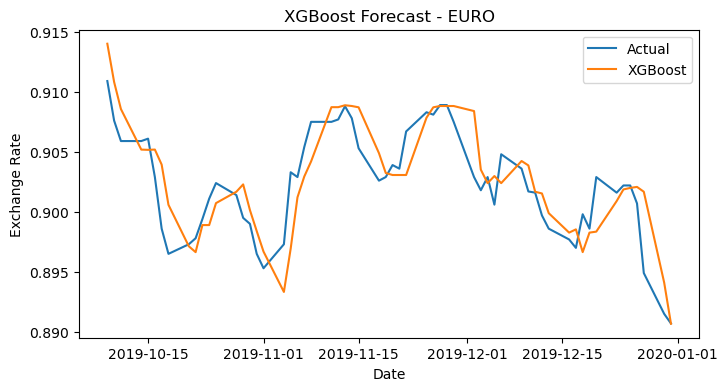

In [129]:
plt.figure(figsize=(8,4))
plt.plot(test_xgb["ds"], y_test, label="Actual")
plt.plot(test_xgb["ds"], test_xgb["xgb_pred"], label="XGBoost")
plt.legend()
plt.title("XGBoost Forecast - EURO")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

In [135]:
results = pd.DataFrame({
    "Model": ["Naive", "ARIMA", "Prophet", "AutoTS", "XGBoost"],
    "MAE": [mae_naive, mae_arima, mae_prophet, mae_autots, mae_xgb],
    "RMSE": [rmse_naive, rmse_arima, rmse_prophet, rmse_autots, rmse_xgb],
    "MAPE": [mape_naive, mape_arima, mape_prophet, mape_autots, mape_xgb]
})

In [136]:
results_sorted = results.sort_values("MAE")
results_sorted

,Model,MAE,RMSE,MAPE
4,XGBoost,0.001849,0.002449,0.205025
1,ARIMA,0.010986,0.011838,1.220026
0,Naive,0.011017,0.011867,1.223400
3,AutoTS,0.018040,0.019260,NaN
2,Prophet,0.043451,0.044145,4.813766


In [133]:
import os
import joblib

joblib.dump(xgb_model, "models/EUR_xgb_model.pkl")
joblib.dump(feature_cols, "models/EUR_xgb_features.pkl")
joblib.dump(df[["ds", "y"]].copy(), "models/EUR_history.pkl")

print("EURO XGBoost model saved successfully.")

EURO XGBoost model saved successfully.


In [137]:
def prepare_currency_df(data, currency_col):
    df = data[["Time Serie", currency_col]].copy()
    df = df.rename(columns={"Time Serie": "ds", currency_col: "y"})
    return df

In [139]:
def split_time_series(df, test_size=60):
    train = df.iloc[:-test_size].copy()
    test = df.iloc[-test_size:].copy()
    return train, test

In [140]:
def run_naive(train, test):
    pred = np.repeat(train["y"].iloc[-1], len(test))
    mae, rmse, mape = evaluate(test["y"], pred)
    return {
        "model_name": "Naive",
        "pred": pred,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [141]:
def run_prophet(train, test):
    model = Prophet()
    model.fit(train)

    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    pred = forecast.tail(len(test))["yhat"].values

    mae, rmse, mape = evaluate(test["y"], pred)
    return {
        "model_name": "Prophet",
        "model": model,
        "pred": pred,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [142]:
def run_autots(train, test):
    model = AutoTS(
        forecast_length=len(test),
        frequency="infer",
        model_list="superfast",
        max_generations=1,
        num_validations=1,
        ensemble=None,
        verbose=0
    )

    model = model.fit(train, date_col="ds", value_col="y", id_col=None)
    prediction = model.predict()
    forecast = prediction.forecast.reset_index()
    forecast.columns = ["ds", "y_pred"]
    pred = forecast["y_pred"].values

    mae, rmse, mape = evaluate(test["y"], pred)
    return {
        "model_name": "AutoTS",
        "model": model,
        "pred": pred,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [143]:
def run_best_arima(train, test, orders=[(1,1,0), (1,1,1), (2,1,1), (3,1,1)]):
    results = []

    for order in orders:
        fitted = ARIMA(train["y"], order=order).fit()
        pred = fitted.forecast(steps=len(test))
        mae, rmse, mape = evaluate(test["y"], pred)

        results.append({
            "order": order,
            "model": fitted,
            "pred": pred,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    best = sorted(results, key=lambda x: x["MAE"])[0]
    return {
        "model_name": "ARIMA",
        "order": best["order"],
        "model": best["model"],
        "pred": best["pred"],
        "MAE": best["MAE"],
        "RMSE": best["RMSE"],
        "MAPE": best["MAPE"]
    }

In [144]:
from xgboost import XGBRegressor

def create_xgb_features(df):
    df_xgb = df.copy()

    df_xgb["lag1"] = df_xgb["y"].shift(1)
    df_xgb["lag2"] = df_xgb["y"].shift(2)
    df_xgb["lag3"] = df_xgb["y"].shift(3)
    df_xgb["lag7"] = df_xgb["y"].shift(7)
    df_xgb["lag14"] = df_xgb["y"].shift(14)

    df_xgb["rolling_mean_7"] = df_xgb["y"].shift(1).rolling(7).mean()
    df_xgb["rolling_std_7"] = df_xgb["y"].shift(1).rolling(7).std()

    df_xgb["dayofweek"] = df_xgb["ds"].dt.dayofweek
    df_xgb["month"] = df_xgb["ds"].dt.month
    df_xgb["year"] = df_xgb["ds"].dt.year

    df_xgb = df_xgb.dropna().reset_index(drop=True)
    return df_xgb

def run_xgboost(df, test_size=60):
    df_xgb = create_xgb_features(df)

    train_xgb = df_xgb.iloc[:-test_size].copy()
    test_xgb = df_xgb.iloc[-test_size:].copy()

    feature_cols = [
        "lag1", "lag2", "lag3", "lag7", "lag14",
        "rolling_mean_7", "rolling_std_7",
        "dayofweek", "month", "year"
    ]

    X_train = train_xgb[feature_cols]
    y_train = train_xgb["y"]
    X_test = test_xgb[feature_cols]
    y_test = test_xgb["y"]

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae, rmse, mape = evaluate(y_test, pred)

    return {
        "model_name": "XGBoost",
        "model": model,
        "pred": pred,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "feature_cols": feature_cols,
        "history": df[["ds", "y"]].copy()
    }

In [145]:
def run_currency_pipeline(data, currency_key, options, test_size=60):
    currency_col = options[currency_key]
    df = prepare_currency_df(data, currency_col)
    train, test = split_time_series(df, test_size=test_size)

    naive_result = run_naive(train, test)
    prophet_result = run_prophet(train, test)
    autots_result = run_autots(train, test)
    arima_result = run_best_arima(train, test)
    xgb_result = run_xgboost(df, test_size=test_size)

    all_results = [
        naive_result,
        prophet_result,
        autots_result,
        arima_result,
        xgb_result
    ]

    results_df = pd.DataFrame([
        {
            "Currency": currency_key,
            "Model": r["model_name"],
            "MAE": r["MAE"],
            "RMSE": r["RMSE"],
            "MAPE": r["MAPE"]
        }
        for r in all_results
    ]).sort_values("MAE")

    best_model_name = results_df.iloc[0]["Model"]
    best_result = next(r for r in all_results if r["model_name"] == best_model_name)

    return {
        "currency": currency_key,
        "results_df": results_df,
        "best_result": best_result,
        "df": df,
        "train": train,
        "test": test
    }

In [146]:
euro_output = run_currency_pipeline(data, "EURO", options, test_size=60)
euro_output["results_df"]

15:34:00 - cmdstanpy - INFO - Chain [1] start processing
15:34:03 - cmdstanpy - INFO - Chain [1] done processing


Template Eval Error: ValueError('maximum supported dimension for an ndarray is currently 64, found 5097') in model 17 in generation 0: BasicLinearModel
Template Eval Error: ValueError('Model SectionalMotif returned NaN for one or more series. fail_on_forecast_nan=True') in model 28 in generation 0: SectionalMotif
Template Eval Error: IndexError('index 3810 is out of bounds for axis 0 with size 1019') in model 34 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 38 in generation 0: SeasonalityMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 49 in generation 0: BasicLinearModel
Template Eval Error: LinAlgError('Singular matrix') in model 51 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 59 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no fu

,Currency,Model,MAE,RMSE,MAPE
4,EURO,XGBoost,0.001849,0.002449,0.205025
3,EURO,ARIMA,0.010986,0.011838,1.220026
0,EURO,Naive,0.011017,0.011867,1.223400
2,EURO,AutoTS,0.018040,0.019260,2.002439
1,EURO,Prophet,0.043451,0.044145,4.813766


In [155]:
all_currency_outputs = {}
all_results_tables = []

for currency in options:
    output = run_currency_pipeline(data, currency, options, test_size=60)
    all_currency_outputs[currency] = output
    all_results_tables.append(output["results_df"])

final_results = pd.concat(all_results_tables, ignore_index=True)
final_results

18:27:17 - cmdstanpy - INFO - Chain [1] start processing
18:27:20 - cmdstanpy - INFO - Chain [1] done processing


Template Eval Error: ValueError('maximum supported dimension for an ndarray is currently 64, found 5097') in model 17 in generation 0: BasicLinearModel
Template Eval Error: ValueError('Model SectionalMotif returned NaN for one or more series. fail_on_forecast_nan=True') in model 28 in generation 0: SectionalMotif
Template Eval Error: IndexError('index 3050 is out of bounds for axis 0 with size 1019') in model 34 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 38 in generation 0: SeasonalityMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 49 in generation 0: BasicLinearModel
Template Eval Error: LinAlgError('Singular matrix') in model 51 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 59 in generation 0: SectionalMotif


18:27:41 - cmdstanpy - INFO - Chain [1] start processing
18:27:44 - cmdstanpy - INFO - Chain [1] done processing


Template Eval Error: ValueError('maximum supported dimension for an ndarray is currently 64, found 5097') in model 17 in generation 0: BasicLinearModel
Template Eval Error: ValueError('Model SectionalMotif returned NaN for one or more series. fail_on_forecast_nan=True') in model 28 in generation 0: SectionalMotif
Template Eval Error: IndexError('index 3810 is out of bounds for axis 0 with size 1019') in model 34 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 38 in generation 0: SeasonalityMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 49 in generation 0: BasicLinearModel
Template Eval Error: LinAlgError('Singular matrix') in model 51 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 59 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer ReconciliationTransfor

18:29:01 - cmdstanpy - INFO - Chain [1] start processing
18:29:05 - cmdstanpy - INFO - Chain [1] done processing


...

18:41:02 - cmdstanpy - INFO - Chain [1] start processing
18:41:06 - cmdstanpy - INFO - Chain [1] done processing


Template Eval Error: ValueError('matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5097 is different from 6000)') in model 17 in generation 0: BasicLinearModel
Template Eval Error: ValueError('Model SectionalMotif returned NaN for one or more series. fail_on_forecast_nan=True') in model 28 in generation 0: SectionalMotif
Template Eval Error: IndexError('index 2720 is out of bounds for axis 0 with size 1019') in model 34 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 38 in generation 0: SeasonalityMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 49 in generation 0: BasicLinearModel
Template Eval Error: LinAlgError('Singular matrix') in model 51 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 59 in generation 0: Sectiona

18:41:44 - cmdstanpy - INFO - Chain [1] start processing
18:41:48 - cmdstanpy - INFO - Chain [1] done processing


Template Eval Error: ValueError('matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5097 is different from 6000)') in model 17 in generation 0: BasicLinearModel
Template Eval Error: ValueError('Model SectionalMotif returned NaN for one or more series. fail_on_forecast_nan=True') in model 28 in generation 0: SectionalMotif
Template Eval Error: IndexError('index 4870 is out of bounds for axis 0 with size 1019') in model 34 in generation 0: SectionalMotif
Template Eval Error: Exception('Transformer FIRFilter failed on fit') in model 38 in generation 0: SeasonalityMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 49 in generation 0: BasicLinearModel
Template Eval Error: LinAlgError('Singular matrix') in model 51 in generation 0: SectionalMotif
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 59 in generation 0: Sectiona

,Currency,Model,MAE,RMSE,MAPE
0,AUSTRALIAN DOLLAR,XGBoost,0.005455,0.006681,0.373764
1,AUSTRALIAN DOLLAR,AutoTS,0.024364,0.028883,1.676966
2,AUSTRALIAN DOLLAR,ARIMA,0.025707,0.028628,1.767916
3,AUSTRALIAN DOLLAR,Naive,0.026107,0.028989,1.795267
4,AUSTRALIAN DOLLAR,Prophet,0.079846,0.082706,5.461654
...,...,...,...,...,...
105,THAI BAHT,XGBoost,0.043707,0.061785,0.144758
106,THAI BAHT,ARIMA,0.131331,0.162998,0.435405
107,THAI BAHT,AutoTS,0.153203,0.182673,0.506991
108,THAI BAHT,Naive,0.162000,0.191946,0.536918


In [158]:
import joblib
from pathlib import Path

def save_best_model(output, save_dir="models"):
    Path(save_dir).mkdir(exist_ok=True)

    currency = output["currency"]
    best = output["best_result"]
    model_name = best["model_name"]

    with open(f"{save_dir}/{currency}_type.txt", "w") as f:
        f.write(model_name)

    if model_name == "Naive":
        joblib.dump(output["df"], f"{save_dir}/{currency}_history.pkl")

    elif model_name in ["ARIMA", "Prophet", "AutoTS"]:
        joblib.dump(best["model"], f"{save_dir}/{currency}_model.pkl")
        joblib.dump(output["df"], f"{save_dir}/{currency}_history.pkl")

    elif model_name == "XGBoost":
        joblib.dump(best["model"], f"{save_dir}/{currency}_model.pkl")
        joblib.dump(best["feature_cols"], f"{save_dir}/{currency}_features.pkl")
        joblib.dump(best["history"], f"{save_dir}/{currency}_history.pkl")

    else:
        raise ValueError(f"Unknown model type: {model_name}")

    print(f"Saved {currency} -> {model_name}")

In [159]:
for currency, output in all_currency_outputs.items():
    save_best_model(output)

Saved AUSTRALIAN DOLLAR -> XGBoost
Saved EURO -> XGBoost
Saved NEW ZEALAND DOLLAR -> XGBoost
Saved GREAT BRITAIN POUNDS -> XGBoost
Saved BRAZILIAN REAL -> XGBoost
Saved CANADIAN DOLLAR -> XGBoost
Saved CHINESE YUAN$ -> XGBoost
Saved HONG KONG DOLLAR -> XGBoost
Saved INDIAN RUPEE -> XGBoost
Saved KOREAN WON$ -> XGBoost
Saved MEXICAN PESO -> XGBoost
Saved SOUTH AFRICAN RAND$ -> XGBoost
Saved SINGAPORE DOLLAR -> XGBoost
Saved DANISH KRONE -> XGBoost
Saved JAPANESE YEN$ -> XGBoost
Saved MALAYSIAN RINGGIT -> XGBoost
Saved NORWEGIAN KRONE -> XGBoost
Saved SWEDEN KRONA -> XGBoost
Saved SRILANKAN RUPEE -> XGBoost
Saved SWISS FRANC -> XGBoost
Saved NEW TAIWAN DOLLAR -> XGBoost
Saved THAI BAHT -> XGBoost
